# Demo 3 — FORCE learning in a chaotic RNN

**Tutorial:** *Synaptic Plasticity and Learning* (CCNSS2026) · Lecture 2

**Idea (Sussillo & Abbott 2009; chaotic substrate from Toyoizumi & Abbott 2011).**
A randomly connected recurrent network with gain $g>1$ is **spontaneously chaotic** — a rich
reservoir of dynamics "beyond the edge of chaos." We *tame* that chaos into a desired output
by learning only the **readout** weights $\mathbf w$ online, with the output fed back into the
network:

$$\tau\dot{\mathbf x} = -\mathbf x + J\,\mathbf r + \mathbf w^{\!f} z,\quad \mathbf r=\tanh\mathbf x,\quad z=\mathbf w^\top\mathbf r.$$

The readout is trained by **recursive least squares (FORCE)**, whose update is driven by the
instantaneous output error $e(t)=z(t)-f(t)$:

$$\mathbf w \leftarrow \mathbf w - e(t)\,P(t)\,\mathbf r,\qquad
P \leftarrow P - \frac{P\,\mathbf r\,\mathbf r^\top P}{1+\mathbf r^\top P\,\mathbf r}.$$

The **scalar error $e(t)$ is the global "third factor"** gating the weight change — the same
motif as the EGHR error gate (Demo 2) and the reward/error term in three-factor rules. Credit
assignment in a *recurrent* network, with a biologically suggestive structure.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
plt.rcParams["figure.dpi"] = 110


## A chaotic reservoir ($g>1$)\nBefore any learning, the network's units fluctuate chaotically — irregular, non-repeating activity.

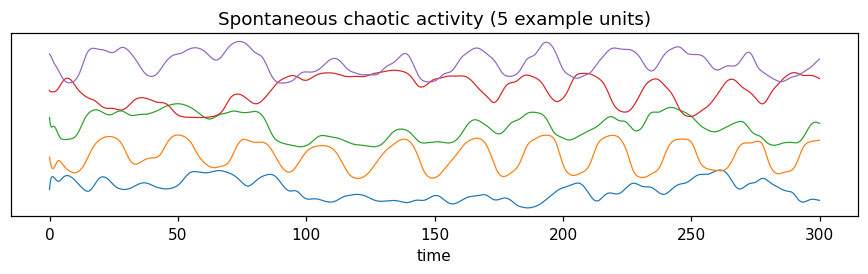

In [2]:
N, g, p = 800, 1.3, 0.1
tau, dt = 1.0, 0.1
J = rng.standard_normal((N, N)) * (g / np.sqrt(p * N))
J *= (rng.random((N, N)) < p)          # sparse connectivity
wf = rng.uniform(-1, 1, N)             # fixed random output-feedback weights

# spontaneous (z feedback off) activity
x = 0.5 * rng.standard_normal(N); r = np.tanh(x)
spont = []
for _ in range(3000):
    x += dt / tau * (-x + J @ r); r = np.tanh(x)
    spont.append(r[:5].copy())
spont = np.array(spont)
plt.figure(figsize=(8, 2.6))
plt.plot(np.arange(3000)*dt, spont + np.arange(5)*1.2, lw=0.8)
plt.yticks([]); plt.xlabel("time"); plt.title("Spontaneous chaotic activity (5 example units)")
plt.tight_layout(); plt.show()


## Target and FORCE training\\nTarget = sum of four sinusoids (a periodic but non-trivial waveform). We train the readout online while feeding $z$ back.

In [3]:
wfund = 0.5
def target(T):
    t = np.arange(T) * dt
    return (np.sin(wfund*t) + 0.5*np.sin(2*wfund*t)
            + (1/6)*np.sin(3*wfund*t) + (1/3)*np.sin(4*wfund*t)) / 1.5

T_train, T_test = 12000, 2000
f = target(T_train + T_test)

P = np.eye(N)              # RLS inverse-correlation estimate, P(0)=I
w = np.zeros(N)            # readout weights (learned)
x = 0.5 * rng.standard_normal(N); r = np.tanh(x); z = 0.0

zs_train, err_train = np.zeros(T_train), np.zeros(T_train)
for ti in range(T_train):
    x += dt / tau * (-x + J @ r + wf * z); r = np.tanh(x); z = float(w @ r)
    if ti % 2 == 0:                       # RLS update every 2 steps
        Pr = P @ r
        k = Pr / (1.0 + r @ Pr)
        e = z - f[ti]                     # global scalar error  (third factor)
        w = w - e * k                     # readout update
        P = P - np.outer(k, Pr)
    zs_train[ti] = z; err_train[ti] = z - f[ti]
print("train |error| (last 1000) RMS =", round(np.sqrt(np.mean(err_train[-1000:]**2)), 4))


train |error| (last 1000) RMS = 0.0346


## Test: free-running reproduction (learning **off**)\nThe trained network must now *autonomously* generate the target with no teacher — only its own feedback.

In [4]:
zs_test = np.zeros(T_test)
for ti in range(T_test):
    x += dt / tau * (-x + J @ r + wf * z); r = np.tanh(x); z = float(w @ r)
    zs_test[ti] = z
ftest = f[T_train:T_train + T_test]
nmse = np.mean((zs_test - ftest)**2) / np.var(ftest)
corr = np.corrcoef(zs_test, ftest)[0, 1]
print("test normalized MSE =", round(nmse, 4), " | test corr =", round(corr, 4))


test normalized MSE = 0.0161  | test corr = 0.9922


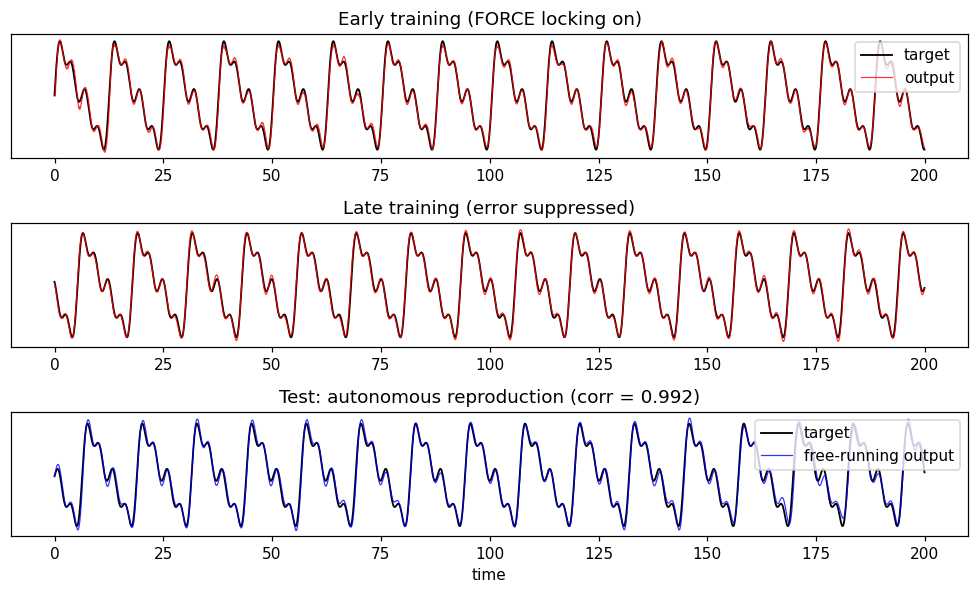

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(9, 5.5))
tt = np.arange(2000) * dt
ax[0].plot(tt, f[:2000], 'k', lw=1.2, label="target")
ax[0].plot(tt, zs_train[:2000], 'r', lw=0.8, alpha=0.8, label="output")
ax[0].set_title("Early training (FORCE locking on)"); ax[0].legend(loc="upper right")
ax[1].plot(tt, f[T_train-2000:T_train], 'k', lw=1.2)
ax[1].plot(tt, zs_train[-2000:], 'r', lw=0.8, alpha=0.8)
ax[1].set_title("Late training (error suppressed)")
ax[2].plot(tt, ftest[:2000], 'k', lw=1.2, label="target")
ax[2].plot(tt, zs_test[:2000], 'b', lw=0.8, alpha=0.8, label="free-running output")
ax[2].set_title(f"Test: autonomous reproduction (corr = {corr:.3f})"); ax[2].legend(loc="upper right")
for a in ax: a.set_yticks([])
ax[2].set_xlabel("time"); plt.tight_layout(); plt.show()


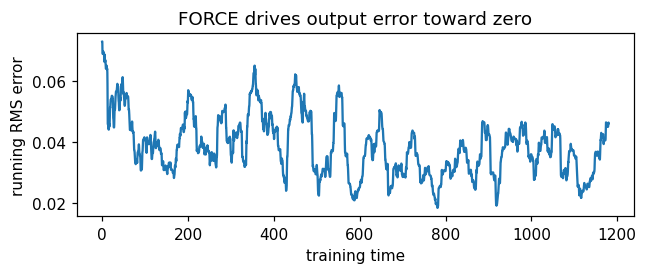

In [6]:
plt.figure(figsize=(6, 2.6))
win = np.convolve(err_train**2, np.ones(200)/200, mode="valid")
plt.plot(np.arange(len(win))*dt, np.sqrt(win))
plt.xlabel("training time"); plt.ylabel("running RMS error")
plt.title("FORCE drives output error toward zero"); plt.tight_layout(); plt.show()


## Takeaways

- **Chaos is a feature.** A network with $g>1$ supplies a rich basis of dynamics; FORCE learns
  a *readout* that selects and stabilizes a target trajectory (Toyoizumi & Abbott 2011 explain
  why the chaotic regime is computationally powerful).
- **One global error, many synapses.** The weight change is gated by the *scalar* error
  $e(t)$ — the **third factor**. This is the recurrent-network analogue of the EGHR error gate
  (Demo 2) and of reward-modulated three-factor plasticity.
- **The journey closes:** *2-factor* (Hebb/Oja, Demo 1) → *a principled objective* (infomax /
  EGHR, Demo 2) → *3-factor learning in networks* (FORCE & friends, Demo 3). One question —
  how does a synapse know how to change? — answered across three scales.
